In [2]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import seaborn as sns
import scienceplots


import sys
sys.path.append("../")

from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

### Figuring out the negative $R_{\rm offset}$ for the bulk flow

In [ ]:
# size, rLG, vx = csiborgtools.flow.load_void_size_variation("gauss", "vx")
# size, rLG, vy = csiborgtools.flow.load_void_size_variation("gauss", "vy")
# size, rLG, vr_grid = csiborgtools.flow.load_void_size_variation("gauss", "vrad", which_run="zoom")
rLG, vr_grid = csiborgtools.flow.load_void_fiducial("gauss", "vrad")


from csiborgtools.flow import (load_void_size_variation, void_bulk_flow,
                               void_monopole)

2025-02-11 03:53:52   loading pre-processed data from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/sizenumber100/processed_fiducial_gauss_vrad.hdf5`.


In [ ]:
void_size = 0.06
rLG = 20
h_void = 0.77
r = np.linspace(0, 200, 100)
phi = jnp.asarray([90.])

size_min = 0.01
size_max = 0.2
rmin = 0
rmax = 400
rLG_min = 0
rLG_max = 50


def f(rLG):
    return csiborgtools.flow.interpolate_fiducial_void(
        void_size, rLG, h_void, r, phi, vr_grid,
        size_min, size_max, rmin, rmax, rLG_min, rLG_max)[0]

# rLG_xrange = np.linspace(-50, 50, 10)
rLG_xrange = [-50, 50]
y = [f(rLG) for rLG in rLG_xrange]


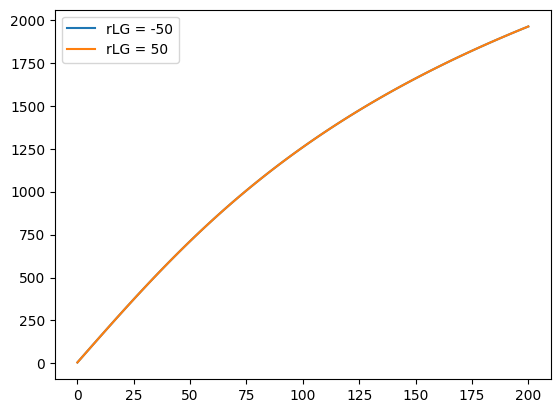

In [ ]:
plt.figure()
for i in range(len(rLG_xrange)):
    plt.plot(r, y[i], label=f"rLG = {rLG_xrange[i]}")

plt.legend()

plt.show()


In [ ]:
def read_void_stats(profile):
    fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_newDecember/void_stats_{profile}.hdf5"

    with File(fname, 'r') as f:
        print(f["void_stats"].keys())
        sizes, rLG, r_grid, phi_grid = [f[f"grid/{x}"][...]
                                        for x in ["sizes", "rLG", "r_grid", "phi_grid"]]
        r_bulk, enclosed_density, monopole, bulk_flow = [
            f[f"void_stats/{x}"][...]
            for x in ["r", "enclosed_density", "monopole", "bulk_flow"]]

        enclosed_density_negrLG, monopole_negrLG, bulk_flow_negrLG = [
            f[f"void_stats/{x}"][...]
            for x in ["enclosed_density_negrLG", "monopole_negrLG", "bulk_flow_negrLG"]]

    return (sizes, rLG, r_grid, phi_grid, r_bulk, enclosed_density, monopole,
            bulk_flow, enclosed_density_negrLG, monopole_negrLG, bulk_flow_negrLG)

In [ ]:
(sizes, rLG, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow,
 enclosed_density_negrLG, monopole_negrLG, bulk_flow_negrLG) = read_void_stats("gauss")

<KeysViewHDF5 ['bulk_flow', 'bulk_flow_negrLG', 'enclosed_density', 'enclosed_density_negrLG', 'monopole', 'monopole_negrLG', 'r']>


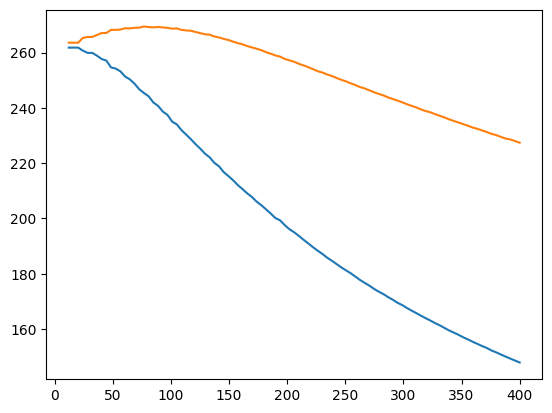

In [ ]:
plt.figure()
plt.plot(r_bulk, np.linalg.norm(bulk_flow[27, 22, ...], axis=-1))
plt.plot(r_bulk, np.linalg.norm(bulk_flow_negrLG[27, 22, ...], axis=-1))
# plt.plot(r_bulk, bulk_flow[27, 22, :, 2]) 
# plt.plot(r_bulk, bulk_flow_negrLG[27, 22, :, 2])
plt.show()

### End of figuring out the bulk flow with negative $R_{\rm offset}$

In [ ]:
def read_void_stats(profile):
    fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/SizeVariation_new/void_stats_{profile}.hdf5"

    with File(fname, 'r') as f:
        sizes, rLG, r_grid, phi_grid = [f[f"grid/{x}"][...]
                                        for x in ["sizes", "rLG", "r_grid", "phi_grid"]]
        r_bulk, enclosed_density, monopole, bulk_flow = [
            f[f"void_stats/{x}"][...]
            for x in ["r", "enclosed_density", "monopole", "bulk_flow"]]

    return sizes, rLG, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow


def bulk_flow_magnitude_with_Vext(fname, profile):
    # Read in the V_ext, rLG, and void_size from the file.
    with File(fname, 'r') as f:
        Vext = f["samples/Vext"][...]
        rLG = f["samples/rLG"][...]

        try:
            void_size = f["samples/void_size"][...]
        except:
            void_size = np.ones_like(rLG)

    # Read in the void statistics
    sizes_grid, rLG_grid, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow = read_void_stats(profile)

    # Snap rLG and void size to the grid values.
    rLG_index = np.argmin(np.abs(rLG[:, None] - rLG_grid[None, :]), axis=1)
    void_size_index = np.argmin(np.abs(void_size[:, None] - sizes_grid[None, :]), axis=1)

    # Get the enclosed density of shape `(nsamples, n_bins)`.
    enclosed_density = enclosed_density[void_size_index, rLG_index]

    # Get the enclosed monopole of shape `(nsamples, n_bins)`.
    monopole = monopole[void_size_index, rLG_index]

    # Get the bulk flow magnitude of shape `(nsamples, n_bins)`.
    bulk_flow = bulk_flow[void_size_index, rLG_index, ...]

    # bulk_flow is now an array with shape `(nsamples, n_bins, 3)`, whereas
    # Vext is an array of shape `(nsamples, 3)`. Want to produce
    # `(nsamples, n_bins, 3)` and then calculate the magnitude to make
    # `(nsamples, n_bins)`.
    bulk_flow_void_only = np.linalg.norm(bulk_flow, axis=-1)
    bulk_flow = np.linalg.norm(bulk_flow + Vext[:, None, :], axis=-1)
    Vext_mag = np.linalg.norm(Vext, axis=-1)

    return r_bulk, enclosed_density, monopole, bulk_flow, bulk_flow_void_only, Vext_mag


def fiducial_bulk_flow_sergij(profile):
    if profile == "exp":
        r_LG = 36
        v_void = 688.56
    elif profile == "gauss":
        r_LG = 39
        v_void = 734.92
    else:
        raise ValueError(f"Profile `{profile}` not recognized.")

    sizes_grid, rLG_grid, r_grid, phi_grid, r_bulk, enclosed_density, monopole, bulk_flow = read_void_stats(profile)
    # Pointing in the Watkins direction.
    v_void = v_void * np.asarray([-0.4035093, 0.01363162, -0.91487399])
    return r_bulk, np.linalg.norm(bulk_flow[27, r_LG] + v_void[None, :], axis=-1)


### Quick checks

In [20]:
with File(fname, 'r') as f:
    phi = f["samples/Vext_phi"][...]
    cos_theta = f["samples/Vext_cos_theta"][...]

theta = np.arccos(cos_theta)

RA = np.rad2deg(phi)
dec = np.rad2deg(np.pi / 2 - theta)

ell, b = csiborgtools.radec_to_galactic(RA, dec)

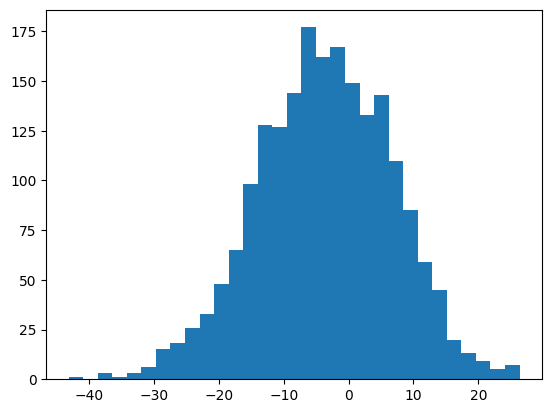

In [22]:
plt.figure()
plt.hist(b, bins="auto")
plt.show()

In [10]:
keys

['Vext', 'l', 'b', 'rLG']

Read in samples are:
 ['Vmag', 'l', 'b', 'rLG', 'aTFR_IndranilVoidTFRMock_0']


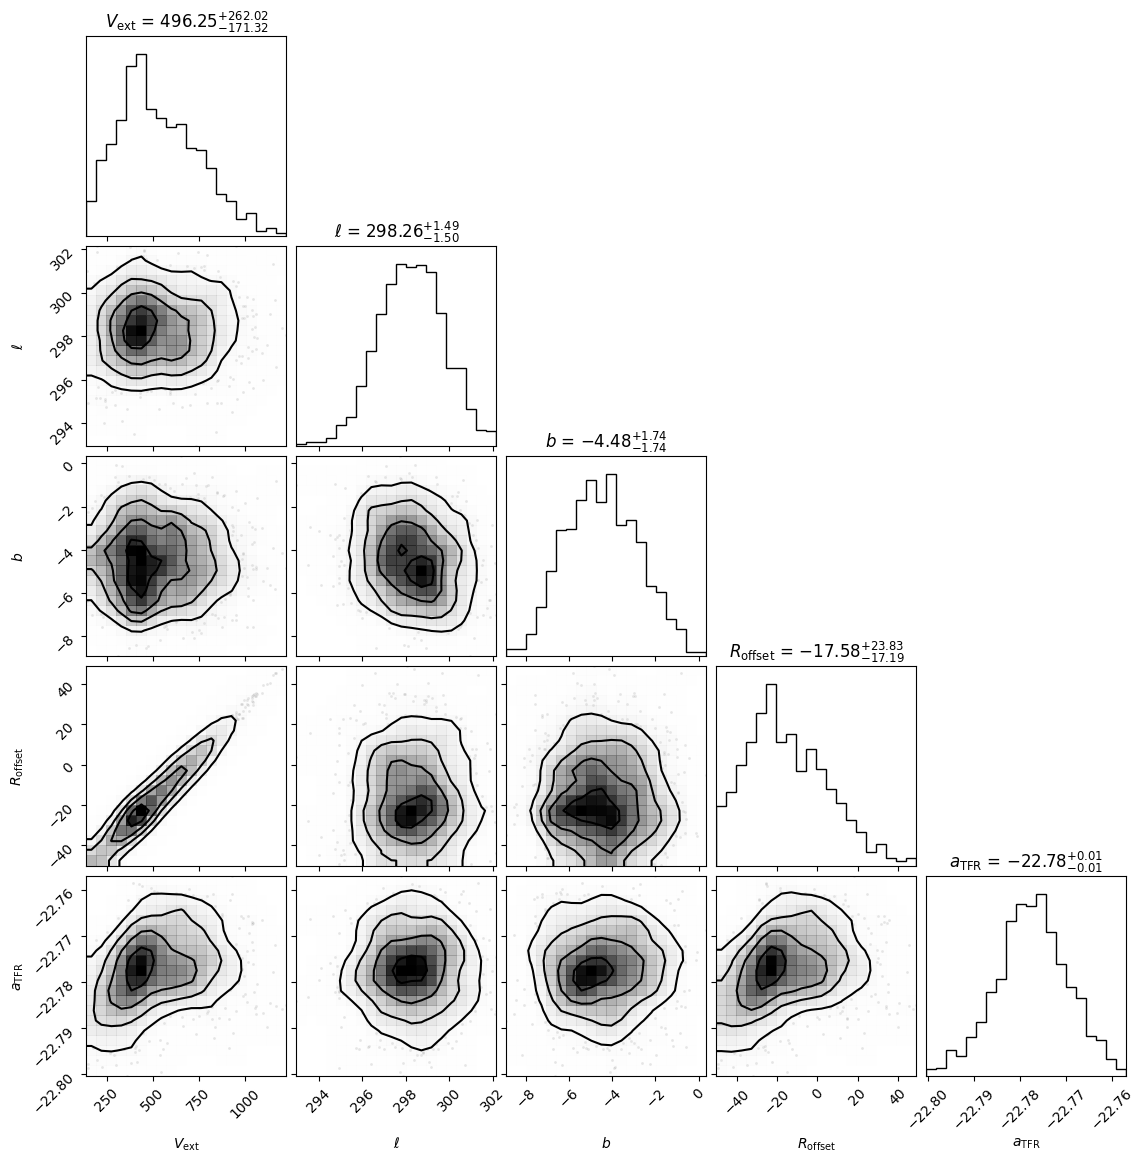

In [34]:
# Degeneracy example in mock:
# fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_IndranilVoidTFRMock_0_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5"

fname = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_gauss_IndranilVoidTFRMock_0_mike_zcmb_max_0.05.hdf5"


# samples = get_some_samples(fname, ["Vext", "rLG", ])
samples = get_some_samples(fname, ["Vext", "rLG", "aTFR"])

print("Read in samples are:\n", list(samples.keys()))
data, labels, keys = samples_for_corner(samples)

fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)

# fig.savefig("../../plots/exp_test.png", dpi=450)
fig.show()

### Sergij's $\chi^2$ grid

In [2]:
kind = "EXP"
fpath = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_{kind}profileresolution_3501x601.dat"  # noqa

print(f"Reading the chi2 grid from `{fpath}`.")
data = np.genfromtxt(fpath)

i, j = np.unravel_index(np.argmin(data), data.shape)
print(f"Minimum chi2: {data[i, j]} at Roffset_index = {i}, Vext_index = {j}.")

Reading the chi2 grid from `/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_EXPprofileresolution_3501x601.dat`.
Minimum chi2: 2.901 at Roffset_index = 689, Vext_index = 36.


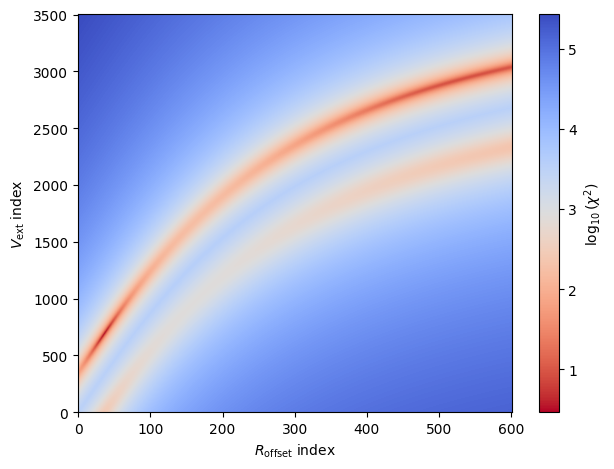

In [6]:
plt.figure()
plt.imshow(np.log10(data), origin="lower", aspect="auto", cmap="coolwarm_r")
plt.colorbar(label=r"$\log_{10}(\chi^2)$")
plt.xlabel(r"$R_{\rm offset}$ index")
plt.ylabel(r"$V_{\rm ext}$ index")
plt.tight_layout()
plt.savefig("test.pdf", dpi=450)
plt.show()

In [7]:
!du -h test.pdf

257K	test.pdf


Read in samples are:
 ['rLG', 'Vmag']


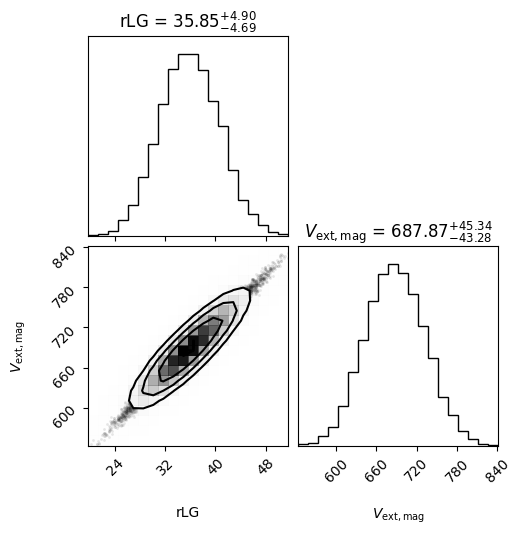

In [41]:
fname = f"/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_{kind}profileresolution_3501x601_samples.hdf5"
samples = get_some_samples(fname, ["rLG", "Vmag"])
print("Read in samples are:\n", list(samples.keys()))

data, labels, keys = samples_for_corner(samples)
fig = corner(data, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)

fig.show()

## Paper plots

### Fiducial analysis

#### Corner plot of the posterior

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05.hdf5
Last modified: 13/02/2025 19:06:28
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05.hdf5
Last modified: 13/02/2025 19:11:55
Removed no burn in
Removed no burn in
Removed no burn in


/tmp/ipykernel_3369614/484886149.py:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


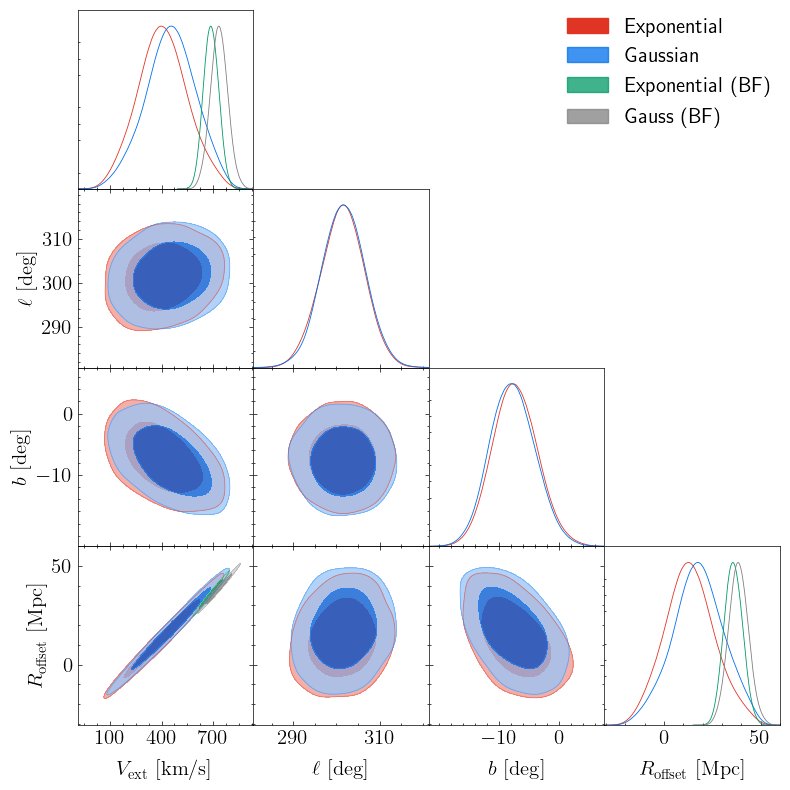

In [52]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
ranges = {}

X = []
for simname in ["IndranilVoid_exp", "IndranilVoid_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="bayes",
        sample_alpha=False, sample_beta=None, zcmb_max=0.05)

    samples = get_some_samples(fname, ["rLG", "Vext"])
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges)
    X.append(X_i)


fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_EXPprofileresolution_3501x601_samples.hdf5"
samples = get_samples(fname, False)
X_i = samples_to_getdist(samples, "Exponential (BF)")
X.append(X_i)

fname = "/mnt/extraspace/rstiskalek/catalogs/IndranilVoid/ChiSq2D_GAUSSprofileresolution_3501x601_samples.hdf5"
samples = get_samples(fname, False)
X_i = samples_to_getdist(samples, "Gauss (BF)")
X.append(X_i)


params = ["Vmag", "l", "b", "rLG"]
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.solid_colors = ['gray', '#009966', '#006FED', '#E03424', '#000866', '#336600', '#006633', 'm', 'r']
    g.settings.legend_fontsize = 18
    g.settings.axes_labelsize = 18
    g.settings.axes_fontsize = 18

    g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_fiducial.pdf", dpi=500, bbox_inches='tight')

#### Predicted void summary statistics

Using h_void = 0.7733393599999999 for profile `exp`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
Last modified: 05/12/2024 22:21:40
Using h_void = 0.7732155199999999 for profile `gauss`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
Last modified: 05/12/2024 22:23:52


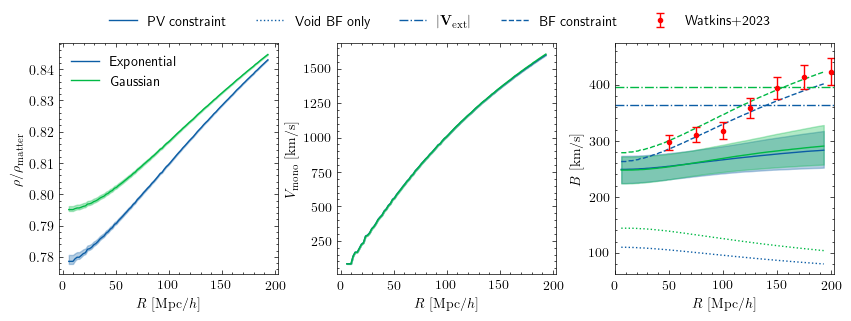

In [ ]:
fnames = []
profiles = ["exp", "gauss"]


with plt.style.context("science"):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    fig.subplots_adjust(wspace=0.27)
    cols = sns.color_palette()

    for n in range(2):
        profile = profiles[n]
        c = cols[n]
        h_void = csiborgtools.flow.select_void_h(100, profile)
        print(f"Using h_void = {h_void} for profile `{profile}`.")

        simname = f"IndranilVoid_{profile}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            sample_alpha=False, sample_beta=None, zcmb_max=0.05)
        fnames.append(fname)

        r_bulk, enclosed_density, monopole, bulk_flow, bulk_flow_void_only, Vext_mag = bulk_flow_magnitude_with_Vext(fname, profile)
        r_bulk_h = r_bulk * h_void


        ylow, ymed, yhigh = np.percentile(enclosed_density, [16, 50, 84], axis=0)
        axs[0].plot(r_bulk_h, ymed, color=c, label=simname_to_pretty(simname))
        axs[0].fill_between(r_bulk_h, ylow, yhigh, alpha=0.3, color=c)
        axs[0].set_ylabel(r"$\rho / \rho_{\rm matter}$")

        ylow, ymed, yhigh = np.percentile(monopole, [16, 50, 84], axis=0)
        axs[1].plot(r_bulk_h, ymed, color=c)
        axs[1].fill_between(r_bulk_h, ylow, yhigh, alpha=0.3, color=c)
        axs[1].set_ylabel(r"$V_{\rm mono} ~ [\mathrm{km} / \mathrm{s}]$")


        ylow, ymed, yhigh = np.percentile(bulk_flow, [16, 50, 84], axis=0)
        axs[2].plot(r_bulk_h, ymed, label="PV constraint" if n == 0 else None,
                    color=c)
        axs[2].fill_between(r_bulk_h, ylow, yhigh, alpha=0.3, color=c)

        # Void bulk flow only
        ymed = np.nanmedian(bulk_flow_void_only, axis=0)
        ymed[ymed == 0] = np.nan
        axs[2].plot(r_bulk_h, ymed, c=c, ls="dotted", label="Void BF only" if n == 0 else None)

        # Vext flow magnitude only
        ymed = np.nanmedian(Vext_mag)
        axs[2].axhline(ymed, c=c, ls="dashdot", label=r"$|\mathbf{V}_{\rm ext}|$" if n == 0 else None)
        
        x, y = fiducial_bulk_flow_sergij(profile)
        axs[2].plot(x * h_void, y, label="BF constraint" if n == 0 else None,
                    color=c, ls="--")

    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])

    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])

    m = r_over_h_watkins < 250
    axs[2].set_xlim(0)

    axs[2].errorbar(r_over_h_watkins[m], bulkflow_watkins[m],
                    yerr=sigma_1_watkins[m], fmt='o', color="red",
                    label="Watkins+2023", ms=3, capsize=3)

    axs[2].set_ylabel(r"$B ~ [\mathrm{km} / \mathrm{s}]$")

    axs[0].legend()
    # axs[2].legend(ncols=2, fontsize="small", )

    # axs[2].legend(
    #     ncols=2,
    #     handlelength=1.5,
    #     # fontsize="small",
    #     loc="lower right",  # Start at the lower-right corner
    #     bbox_to_anchor=(1.0, 0.16)  # Adjust x and y coordinates
    #     )
    axs[2].legend(
        ncols=5,  # Single row (spread items across columns to form a row)
        loc="lower center",  # Position at the bottom center of the bounding box
        bbox_to_anchor=(-0.8, 1.01),  # Center horizontally and move above the axes
        )

    for ax in axs:
        ax.set_xlabel(r"$R ~ [\mathrm{Mpc} / h]$")

    # fig.tight_layout()
    fig.savefig("../../plots/bulk_flow_fiducial.pdf", dpi=300, bbox_inches='tight')
    fig.show()


### Extended analysis, varying the void size

#### Corner plot

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 14/02/2025 02:42:59
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 14/02/2025 00:42:09
Removed no burn in


/tmp/ipykernel_3369614/2149512743.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


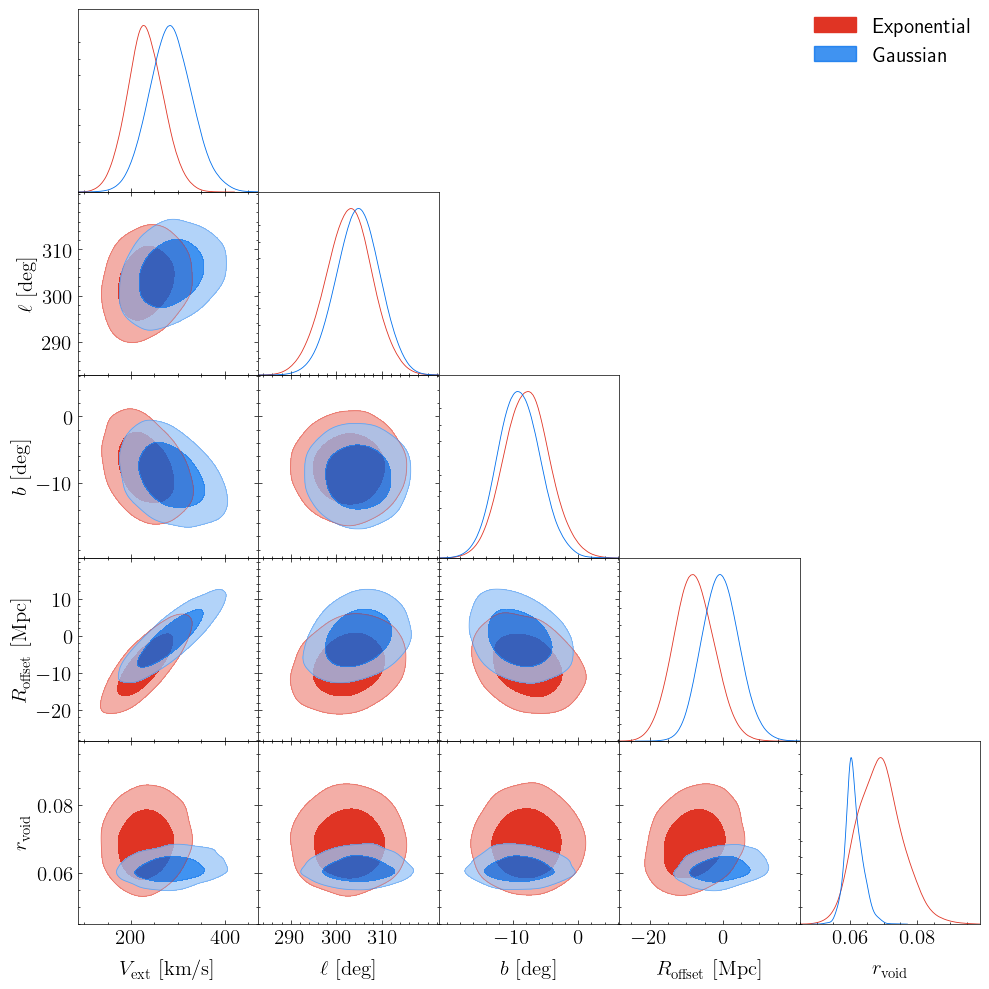

In [50]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']
# catalogue = ['LOSS', 'Foundation']

ranges={
    'void_size':[0.01, 0.2],
    # 'void_size':[0.1, 3.0],
    'rLG': [-50, 50],
    }

X = []
for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="bayes",
        sample_alpha=False, sample_beta=None,
        zcmb_max=0.05, which_void_size_run="zoom")

    samples = get_some_samples(fname, ["rLG", "Vext", "void_size"])
    X_i = samples_to_getdist(samples, simname_to_pretty(simname), ranges=ranges)
    X.append(X_i)


# params = ["Vmag", "l", "b", "rLG", "void_size"]
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 18
    g.settings.axes_labelsize = 18
    g.settings.axes_fontsize = 18

    g.triangle_plot(X, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../../plots/void_extended.pdf", dpi=500, bbox_inches='tight')

#### Gaussian plot restricted to large sizes 

#### Void statistics

Using h_void = 0.7733393599999999 for profile `exp`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 05/12/2024 22:45:33
Using h_void = 0.7732155199999999 for profile `gauss`.
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 05/12/2024 22:47:02


/mnt/users/rstiskalek/csiborgtools/venv_csiborg/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/tmp/ipykernel_1947110/1627463702.py:73: DeprecationWarning: Calling nonzero on 0d arrays is deprecated, as it behaves surprisingly. Use `atleast_1d(cond).nonzero()` if the old behavior was intended. If the context of this warning is of the form `arr[nonzero(cond)]`, just use `arr[cond]`.
  ax.set_xlim(r_bulk_h[np.where(np.isfinite(ymed))[0][0]], r_bulk_h.max())


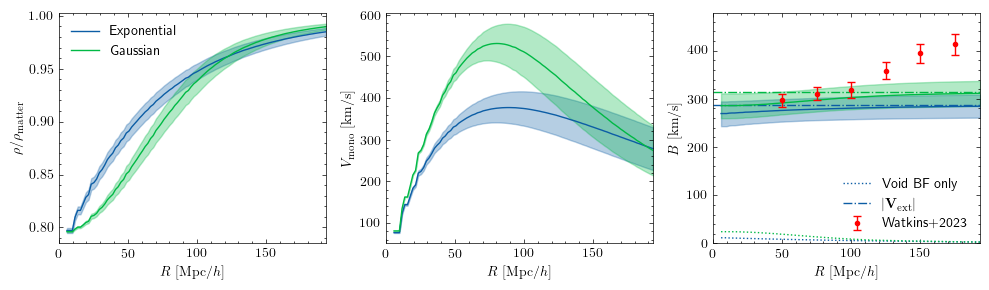

In [ ]:
profiles = ["exp", "gauss"]


with plt.style.context("science"):
    fig, axs = plt.subplots(1, 3, figsize=(10, 3))
    cols = sns.color_palette()

    for n in range(2):
        profile = profiles[n]
        c = cols[n]
        h_void = csiborgtools.flow.select_void_h(100, profile)
        print(f"Using h_void = {h_void} for profile `{profile}`.")

        simname = f"IndranilVoidSizeVar_{profile}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            sample_alpha=False, sample_beta=None, zcmb_max=0.05,
            which_void_size_run="zoom")

        r_bulk, enclosed_density, monopole, bulk_flow, bulk_flow_void_only, Vext_mag = bulk_flow_magnitude_with_Vext(fname, profile)
        r_bulk_h = r_bulk * h_void

        ymed = np.mean(enclosed_density, axis=0)
        ystd = np.std(enclosed_density, axis=0)
        ylow = ymed - ystd
        yhigh = ymed + ystd
        axs[0].plot(r_bulk_h, ymed, color=c, label=simname_to_pretty(simname.replace("SizeVar", "")))
        axs[0].fill_between(r_bulk_h, ylow, yhigh, alpha=0.3, color=c)
        axs[0].set_ylabel(r"$\rho / \rho_{\rm matter}$")

        ymed = np.mean(monopole, axis=0)
        ystd = np.std(monopole, axis=0)
        ylow = ymed - ystd
        yhigh = ymed + ystd
        axs[1].plot(r_bulk_h, ymed, color=c)
        axs[1].fill_between(r_bulk_h, ylow, yhigh, alpha=0.3, color=c)
        axs[1].set_ylabel(r"$V_{\rm mono} ~ [\mathrm{km} / \mathrm{s}]$")


        ylow, ymed, yhigh = np.percentile(bulk_flow, [16, 50, 84], axis=0)
        axs[2].plot(r_bulk_h, ymed, color=c)
        axs[2].fill_between(r_bulk_h, ylow, yhigh, alpha=0.3, color=c)

        # Void bulk flow only
        ymed = np.nanmedian(bulk_flow_void_only, axis=0)
        ymed[ymed == 0] = np.nan
        axs[2].plot(r_bulk_h, ymed, c=c, ls="dotted", label="Void BF only" if n == 0 else None)

        # Vext flow magnitude only
        ymed = np.nanmedian(Vext_mag)
        axs[2].axhline(ymed, c=c, ls="dashdot", label=r"$|\mathbf{V}_{\rm ext}|$" if n == 0 else None)

    r_over_h_watkins = np.array([50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0])
    bulkflow_watkins =np.array([297.0, 311.0, 318.28218822, 358.20760135, 394.55416487, 413.44319113, 423.37248285, 429.49627515, 432.53804634])
    sigma_1_watkins = np.array([14.0, 14.0, 15.9, 17.5, 19.4, 21.6, 23.7, 25.4, 26.9])

    m = r_over_h_watkins < 250

    axs[2].errorbar(r_over_h_watkins[m], bulkflow_watkins[m],
                    yerr=sigma_1_watkins[m], fmt='o', color="red",
                    label="Watkins+2023", ms=3, capsize=3)

    axs[2].set_ylabel(r"$B ~ [\mathrm{km} / \mathrm{s}]$")

    axs[2].set_xlim(0)
    axs[2].set_ylim(0)

    axs[0].legend()
    axs[2].legend()

    for ax in axs:
        ax.set_xlabel(r"$R ~ [\mathrm{Mpc} / h]$")
        ax.set_xlim(r_bulk_h[np.where(np.isfinite(ymed))[0][0]], r_bulk_h.max())

    fig.tight_layout()
    fig.savefig("../../plots/bulk_flow_vary_size.pdf", dpi=300)
    fig.show()

### Predited void $H_0$

#### $H_0$ PPD

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 14/02/2025 02:42:59
exp 69.67868 0.38069567
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_bayes_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 14/02/2025 00:42:09
gauss 69.33998 0.19128627


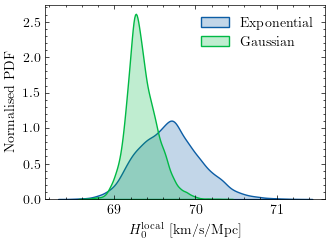

In [29]:
from interpax import Interpolator1D

profiles = ["exp", "gauss"]


with plt.style.context("science"):
    plt.figure()

    for n in range(2):
        profile = profiles[n]
        simname = f"IndranilVoidSizeVar_{profile}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="bayes",
            sample_alpha=False, sample_beta=None, zcmb_max=0.05,
            which_void_size_run="zoom")

        void_size, h_void = csiborgtools.flow.select_void_h(
            None, profile, return_all=True)

        # Check if the mapping is in H0 or h and sizes in percent
        void_size_to_h_void = Interpolator1D(
            void_size / 100, h_void, method="linear")

        with File(fname, 'r') as f:
            void_size = f["samples/void_size"][...]

        h_void = void_size_to_h_void(void_size)
        print(profile, 100 * h_void.mean(), 100 * h_void.std())

        sns.kdeplot(h_void * 100,
                    label=simname_to_pretty(f"IndranilVoid_{profile}"),
                    fill=True)

    plt.xlabel(r"$H_0^{\rm local} ~ [\mathrm{km} / \mathrm{s} / \mathrm{Mpc}]$")
    plt.ylabel("Normalised PDF")
    plt.legend()
    plt.tight_layout()
    plt.savefig("../../../plots/h_void_distribution.pdf", dpi=300)
    plt.show()

#### $H_0$ dependence on the void size

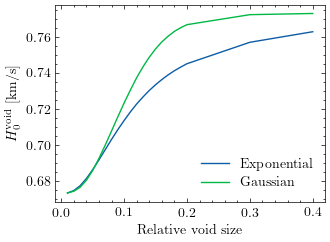

In [63]:
with plt.style.context("science"):
    plt.figure()
    for profile in ["exp", "gauss", ]:
        void_size, h_void = csiborgtools.flow.select_void_h(
                 None, profile, return_all=True)
        m = void_size < 50
        plt.plot(void_size [m]/ 100, h_void[m],
                 label=simname_to_pretty(f"IndranilVoid_{profile}"))
    plt.xlabel("Relative void size")
    plt.ylabel(r"$H_0^{\rm void} ~ [\mathrm{km} / \mathrm{s}]$")
    plt.legend()

    plt.tight_layout()
    # plt.savefig("../../plots/h_void_vs_void_size.png", dpi=300)
    plt.show()


### Evidence comparison

In [45]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

X = {}
for simname in ["no_field",
                "IndranilVoid_exp", "IndranilVoid_gauss",
                "IndranilVoidSizeVar_exp",
                "IndranilVoidSizeVar_gauss",
                ]:

    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        sample_alpha=False, sample_beta=None, no_Vext=None,
        zcmb_max=0.05,
        which_void_size_run="zoom" if "SizeVar" in simname else None
        )

    X[simname] = -get_gof("neg_lnZ_harmonic", fname) / np.log(10)


for simname in ["Carrick2015", "CF4"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        sample_alpha=True, sample_beta=None,
        zcmb_max=0.05)
    X[simname] = - get_gof("neg_lnZ_harmonic", fname) / np.log(10)

# Take 'IndranilVoid_gass' as a reference
ref = X["no_field"]
for key in X:
    X[key] -= ref

for key in list(X.keys()):
    val = X.pop(key)
    X[simname_to_pretty(key)] = round(val, 2)

print()
for key, val in X.items():
    print(f"{key}: {val}")

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
Last modified: 13/02/2025 02:40:17
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
Last modified: 13/02/2025 18:25:21
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
Last modified: 13/02/2025 19:00:08
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_which_void_size_run_zoom.hdf5
Last modified: 13/02/2025 20:14:13
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_which_void_size_run_zoom.

#### Evidence dependence on the void size 

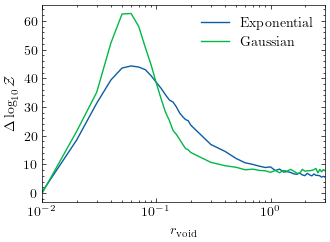

In [32]:
catalogue = ['CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

sizes = np.asarray([n for n in range(1, 20)] + [10 * n for n in range(2, 31)])

def void_gof_sizevar(kind, gof):
    y = np.full_like(sizes, np.nan, dtype=float)
    for i, size in enumerate(sizes):
        simname = f"IndranilVoid{size}_{kind}"
        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            sample_alpha=False, sample_beta=None,
            zcmb_max=0.05, verbose_print=False)
        if exists(fname):
            y[i] = get_gof(gof, fname)
    return y


logZ = - np.stack([void_gof_sizevar("exp", "neg_lnZ_harmonic"),
                   void_gof_sizevar("gauss", "neg_lnZ_harmonic"),])
logZ /= np.log(10)
logZ -= np.nanmin(logZ)

sizes = sizes / 100

logZ[0][14] = np.nan

m = np.isfinite(logZ[0])
from scipy.interpolate import interp1d
logZ[0, ~m] = interp1d(sizes[m], logZ[0, m], kind="cubic")(sizes[~m])


with plt.style.context("science"):
    plt.figure()
    m = sizes > 0
    plt.plot(sizes[m], logZ[0][m], label=simname_to_pretty("IndranilVoid_exp"))
    plt.plot(sizes[m], logZ[1][m], label=simname_to_pretty("IndranilVoid_gauss"))

    plt.xlim(sizes.min(), sizes.max())
    plt.xlabel(r"$r_{\rm void}$")
    plt.ylabel(r"$\Delta \log_{10} \mathcal{Z}$")
    plt.legend()
    plt.xscale("log")

    plt.tight_layout()
    plt.savefig("../../../plots/void_size_var.pdf", dpi=300)
    plt.show()



### Extended analysis, varying the void size and $\beta$

#### Corner plot

File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5
Last modified: 19/12/2024 15:27:59
Removed no burn in
File:          /mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoidSizeVar_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_beta_which_void_size_run_zoom.hdf5
Last modified: 19/12/2024 13:08:11
Removed no burn in


/tmp/ipykernel_1947110/1037148779.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.gcf().tight_layout()


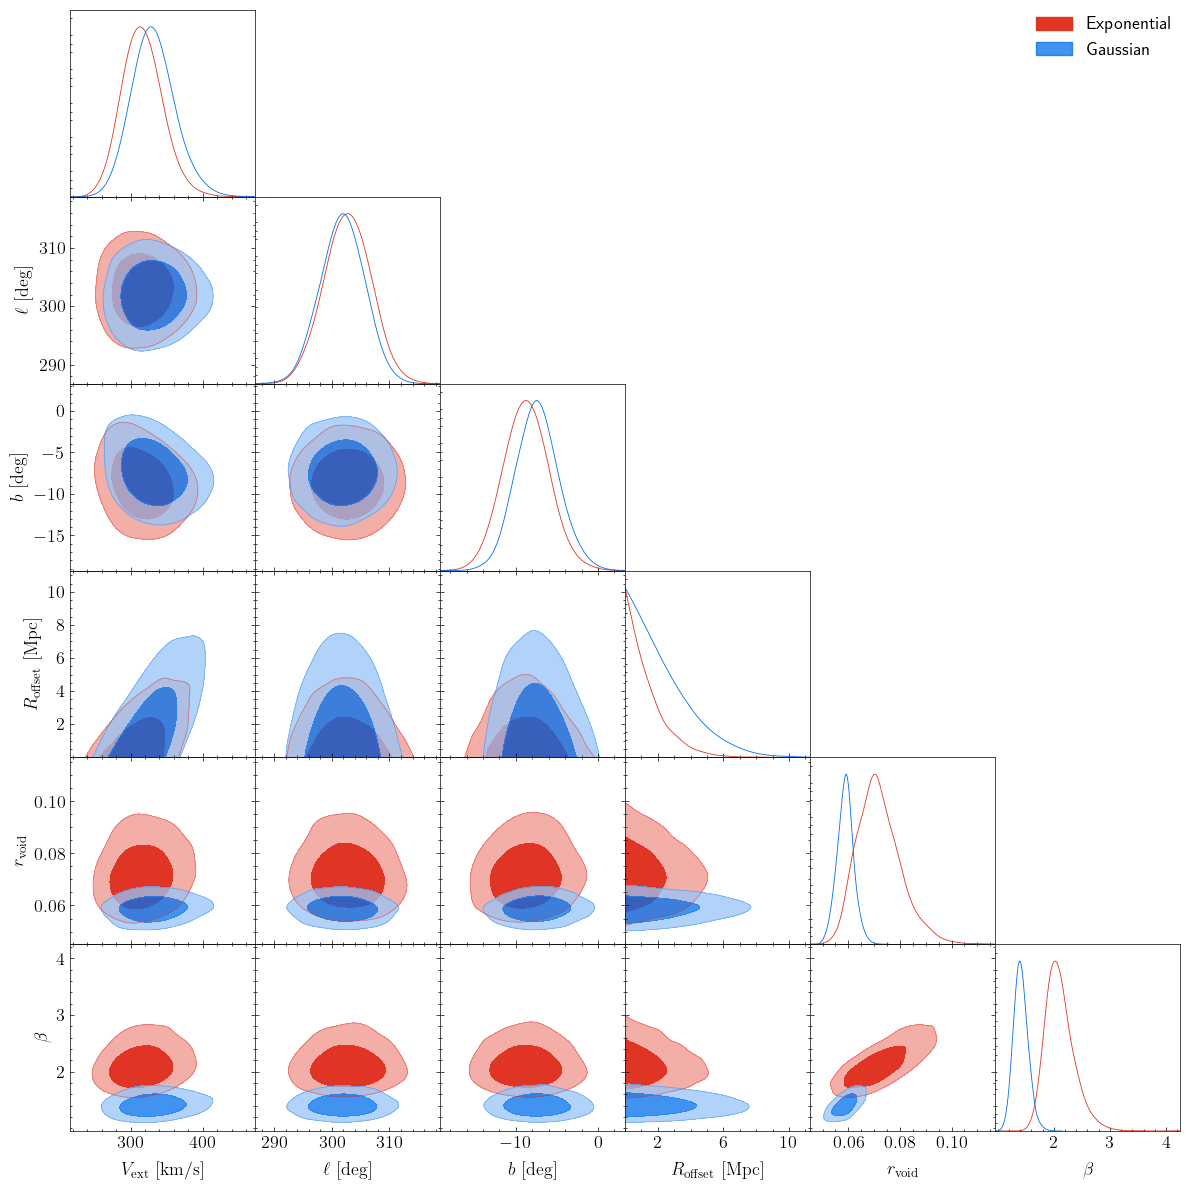

In [ ]:
catalogue = ['LOSS', 'Foundation', 'CF4_TFR_i', 'CF4_TFR_notSDSS_w1']

ranges={
    'void_size':[0.01, 0.2],
    # 'void_size':[0.1, 3.0],
    'rLG': [0, 50],
    }

X = []
for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss"]:
    fname = paths.flow_validation(
        fdir, simname, catalogue, inference_method="mike",
        sample_alpha=False, sample_beta=True,
        zcmb_max=0.05, which_void_size_run="zoom")

    X_i = samples_to_getdist(get_samples(fname, True), simname_to_pretty(simname.replace("SizeVar", "")), ranges=ranges)
    X.append(X_i)


params = ["Vmag", "l", "b", "rLG", "void_size", "beta"]
with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75
    g.settings.legend_fontsize = 16
    g.settings.axes_labelsize = 16
    g.settings.axes_fontsize = 16

    g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
    plt.gcf().tight_layout()
    plt.gcf().show()
    plt.gcf().savefig(f"../../plots/void_extended_with_beta.pdf", dpi=500, bbox_inches='tight')